In [186]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Best options for classification target: \
Inventory_Status (Days_of_Inventory, Avg_Daily_Sales, Reorder_Point, Safety_Stock, Lead_Time_Days)\
ABC_Class (Total_Inventory_Value_USD, Avg_Daily_Sales, Order_Frequency_per_month)\
convert a numeric variable to categorical (SKU_Churn_Rate or Demand_Forecast_Accuracy_PCT)

Data Cleaning

In [239]:
data = pd.read_csv("Inventory Management E-Grocery - InventoryData.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12  Stock_Age_Days                1000 non-null   int64  
 13  Quan

In [240]:
data.iloc[:,1:20]

,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,Last_Purchase_Date,Expiry_Date,Stock_Age_Days,Quantity_On_Hand,Quantity_Reserved,Quantity_Committed,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d
0,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,2025-06-01,2027-04-25,57,359,100,36,0,0,"28,57",971.000
1,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,2025-02-22,2025-04-11,154,314,64,0,0,1,"34,99",796.000
2,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,2025-02-26,2025-04-02,178,485,28,62,3,1,"36,55",1.377
3,Seafood Product 48,Seafood,A,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH5333,2025-06-10,2025-04-20,2025-06-18,91,281,92,49,0,0,"25,49",716.000
4,Personal Product 194,Personal Care,A,S002,PT Indo Fresh,WHDPS,Denpasar - Tabanan,BATCH6925,2025-06-26,2025-05-21,2030-01-03,75,235,63,33,0,2,"17,05",518.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Fresh Product 377,Fresh Produce,C,S006,PT Frozen Express,WHJKT,Jakarta - Cengkareng,BATCH8871,2025-07-20,2025-06-02,2025-07-25,51,382,64,48,1,0,"31,90",678.000
996,Frozen Product 125,Frozen,C,S001,PT Segar Makmur,WHDPS,Denpasar - Tabanan,BATCH9906,2025-03-16,2025-03-09,2025-11-19,177,208,27,96,0,1,"40,03",1.019
997,Fresh Product 454,Fresh Produce,C,S007,PT Bakerindo,WHBDG,Bandung - Rancaekek,BATCH1393,2025-09-09,2025-08-26,2025-09-15,0,264,48,13,1,2,"26,13",797.000
998,Meat Product 451,Meat,C,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH2804,2025-05-07,2025-04-23,2025-05-17,125,33,33,0,2,2,"23,48",676.000


In [241]:
data.iloc[:,20:37]

,Days_of_Inventory,Reorder_Point,Safety_Stock,Lead_Time_Days,Unit_Cost_USD,Last_Purchase_Price_USD,Total_Inventory_Value_USD,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,"12,57",51.0,22,1,"$5,81","$5,71","$2.084,25","2,39","5,00","70,68%",FIFO,In Stock,0,2025-06-26,"-7,14%","95,67%",NaN
1,"8,97",744.0,254,14,"$1,45","$1,33","$456,71","3,34","12,00","84,61%",FEFO,Low Stock,4,2025-08-12,"2,15%","86,00%",NaN
2,"13,27",225.0,79,4,"$1,86","$1,69","$902,63","2,26","11,00","85,36%",FIFO,Expiring Soon,-5,2025-08-13,"6,85%","87,64%",NaN
3,"11,02",162.0,60,4,"$14,50","$14,12","$4.073,15","2,72","10,00","72,81%",FIFO,Expiring Soon,0,2025-07-13,"-6,69%","71,15%",NaN
4,"13,78",80.0,29,3,"$9,46","$10,31","$2.222,91","2,18","2,00","70,93%",FIFO,In Stock,-5,2025-06-11,"1,23%","76,25%",High return rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"11,97",485.0,166,10,"$0,99","$1,05","$379,21","2,51","8,00","79,06%",FEFO,Low Stock,2,2025-08-20,"-6,23%","80,85%",NaN
996,"5,20",307.0,107,5,"$2,54","$2,31","$527,28","5,77","15,00","74,40%",FIFO,Low Stock,0,2025-09-04,"1,33%","88,43%",Promotional item
997,"10,10",394.0,133,10,"$0,69","$0,71","$181,39","2,97","9,00","92,17%",FEFO,Low Stock,0,2025-07-22,"5,47%","91,92%",Promotional item
998,"1,41",181.0,64,5,"$2,38","$2,71","$78,48","21,35","13,00","92,40%",FIFO,Low Stock,0,2025-08-04,"0,46%","93,18%",NaN


In [242]:
def clean_symbols(col):
    col = col.astype(str)

    # Remove currency + percent symbols FIRST
    col = col.str.replace(r'[\$]', '', regex=True)  # removes $ and commas

    # Remove % separately (so we can optionally divide later)
    col = col.str.replace('%', '', regex=False)

    return col

def clean_numeric_column(col, is_percent=False):
    col = col.astype(str)
    
    # Handle European format: 1.234,56 → 1234.56
    col = col.str.replace(r'\.(?=\d{3}(?:,|$))', '', regex=True)
    col = col.str.replace(',', '.', regex=False)

    # Convert to numeric
    col = pd.to_numeric(col, errors='coerce')

    # Convert percentages if needed
    if is_percent:
        col = col / 100

    return col

In [243]:
data['Last_Purchase_Price_USD'] = clean_symbols(data['Last_Purchase_Price_USD'])
data['Total_Inventory_Value_USD'] = clean_symbols(data['Total_Inventory_Value_USD'])
data['Unit_Cost_USD'] = clean_symbols(data['Unit_Cost_USD'])
data['Supplier_OnTime_Pct'] = clean_symbols(data['Supplier_OnTime_Pct'])
data['Audit_Variance_Pct'] = clean_symbols(data['Audit_Variance_Pct'])
data['Demand_Forecast_Accuracy_Pct'] = clean_symbols(data['Demand_Forecast_Accuracy_Pct'])

In [244]:
data['Avg_Daily_Sales'] = clean_numeric_column(data['Avg_Daily_Sales'])
data['Days_of_Inventory'] = clean_numeric_column(data['Days_of_Inventory'])
data['Unit_Cost_USD'] = clean_numeric_column(data['Unit_Cost_USD'])
data['Last_Purchase_Price_USD'] = clean_numeric_column(data['Last_Purchase_Price_USD'])
data['Total_Inventory_Value_USD'] = clean_numeric_column(data['Total_Inventory_Value_USD'])
data['SKU_Churn_Rate'] = clean_numeric_column(data['SKU_Churn_Rate'])
data['Order_Frequency_per_month'] = clean_numeric_column(data['Order_Frequency_per_month'])
data['Supplier_OnTime_Pct'] = clean_numeric_column(data['Supplier_OnTime_Pct'], is_percent=True)
data['Audit_Variance_Pct'] = clean_numeric_column(data['Audit_Variance_Pct'], is_percent=True)
data['Demand_Forecast_Accuracy_Pct'] = clean_numeric_column(data['Demand_Forecast_Accuracy_Pct'], is_percent=True)

In [245]:
data['Forecast_Next_30d'] = (data['Forecast_Next_30d'] * 1000).astype(int)

In [246]:
data.iloc[:,1:20]

,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,Last_Purchase_Date,Expiry_Date,Stock_Age_Days,Quantity_On_Hand,Quantity_Reserved,Quantity_Committed,Damaged_Qty,Returns_Qty,Avg_Daily_Sales,Forecast_Next_30d
0,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,2025-06-01,2027-04-25,57,359,100,36,0,0,28.57,971000
1,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,2025-02-22,2025-04-11,154,314,64,0,0,1,34.99,796000
2,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,2025-02-26,2025-04-02,178,485,28,62,3,1,36.55,1377
3,Seafood Product 48,Seafood,A,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH5333,2025-06-10,2025-04-20,2025-06-18,91,281,92,49,0,0,25.49,716000
4,Personal Product 194,Personal Care,A,S002,PT Indo Fresh,WHDPS,Denpasar - Tabanan,BATCH6925,2025-06-26,2025-05-21,2030-01-03,75,235,63,33,0,2,17.05,518000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Fresh Product 377,Fresh Produce,C,S006,PT Frozen Express,WHJKT,Jakarta - Cengkareng,BATCH8871,2025-07-20,2025-06-02,2025-07-25,51,382,64,48,1,0,31.90,678000
996,Frozen Product 125,Frozen,C,S001,PT Segar Makmur,WHDPS,Denpasar - Tabanan,BATCH9906,2025-03-16,2025-03-09,2025-11-19,177,208,27,96,0,1,40.03,1018
997,Fresh Product 454,Fresh Produce,C,S007,PT Bakerindo,WHBDG,Bandung - Rancaekek,BATCH1393,2025-09-09,2025-08-26,2025-09-15,0,264,48,13,1,2,26.13,797000
998,Meat Product 451,Meat,C,S007,PT Bakerindo,WHJKT,Jakarta - Cengkareng,BATCH2804,2025-05-07,2025-04-23,2025-05-17,125,33,33,0,2,2,23.48,676000


In [247]:
data.iloc[:,20:37]

,Days_of_Inventory,Reorder_Point,Safety_Stock,Lead_Time_Days,Unit_Cost_USD,Last_Purchase_Price_USD,Total_Inventory_Value_USD,SKU_Churn_Rate,Order_Frequency_per_month,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes
0,12.57,51.0,22,1,5.81,5.71,2084.25,2.39,5.0,0.7068,FIFO,In Stock,0,2025-06-26,-0.0714,0.9567,NaN
1,8.97,744.0,254,14,1.45,1.33,456.71,3.34,12.0,0.8461,FEFO,Low Stock,4,2025-08-12,0.0215,0.8600,NaN
2,13.27,225.0,79,4,1.86,1.69,902.63,2.26,11.0,0.8536,FIFO,Expiring Soon,-5,2025-08-13,0.0685,0.8764,NaN
3,11.02,162.0,60,4,14.50,14.12,4073.15,2.72,10.0,0.7281,FIFO,Expiring Soon,0,2025-07-13,-0.0669,0.7115,NaN
4,13.78,80.0,29,3,9.46,10.31,2222.91,2.18,2.0,0.7093,FIFO,In Stock,-5,2025-06-11,0.0123,0.7625,High return rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,11.97,485.0,166,10,0.99,1.05,379.21,2.51,8.0,0.7906,FEFO,Low Stock,2,2025-08-20,-0.0623,0.8085,NaN
996,5.20,307.0,107,5,2.54,2.31,527.28,5.77,15.0,0.7440,FIFO,Low Stock,0,2025-09-04,0.0133,0.8843,Promotional item
997,10.10,394.0,133,10,0.69,0.71,181.39,2.97,9.0,0.9217,FEFO,Low Stock,0,2025-07-22,0.0547,0.9192,Promotional item
998,1.41,181.0,64,5,2.38,2.71,78.48,21.35,13.0,0.9240,FIFO,Low Stock,0,2025-08-04,0.0046,0.9318,NaN


EDA

In [119]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12  Stock_Age_Days                1000 non-null   int64  
 13  Quan

Exploratory Data Analysis

In [79]:
data['Inventory_Status'].unique()

array(['In Stock', 'Low Stock', 'Expiring Soon', 'Out of Stock'],
      dtype=object)

In [80]:
data['ABC_Class'].unique()

array(['A', 'C', 'B'], dtype=object)

In [81]:
data.columns[data.isnull().any()].tolist()

['Notes']

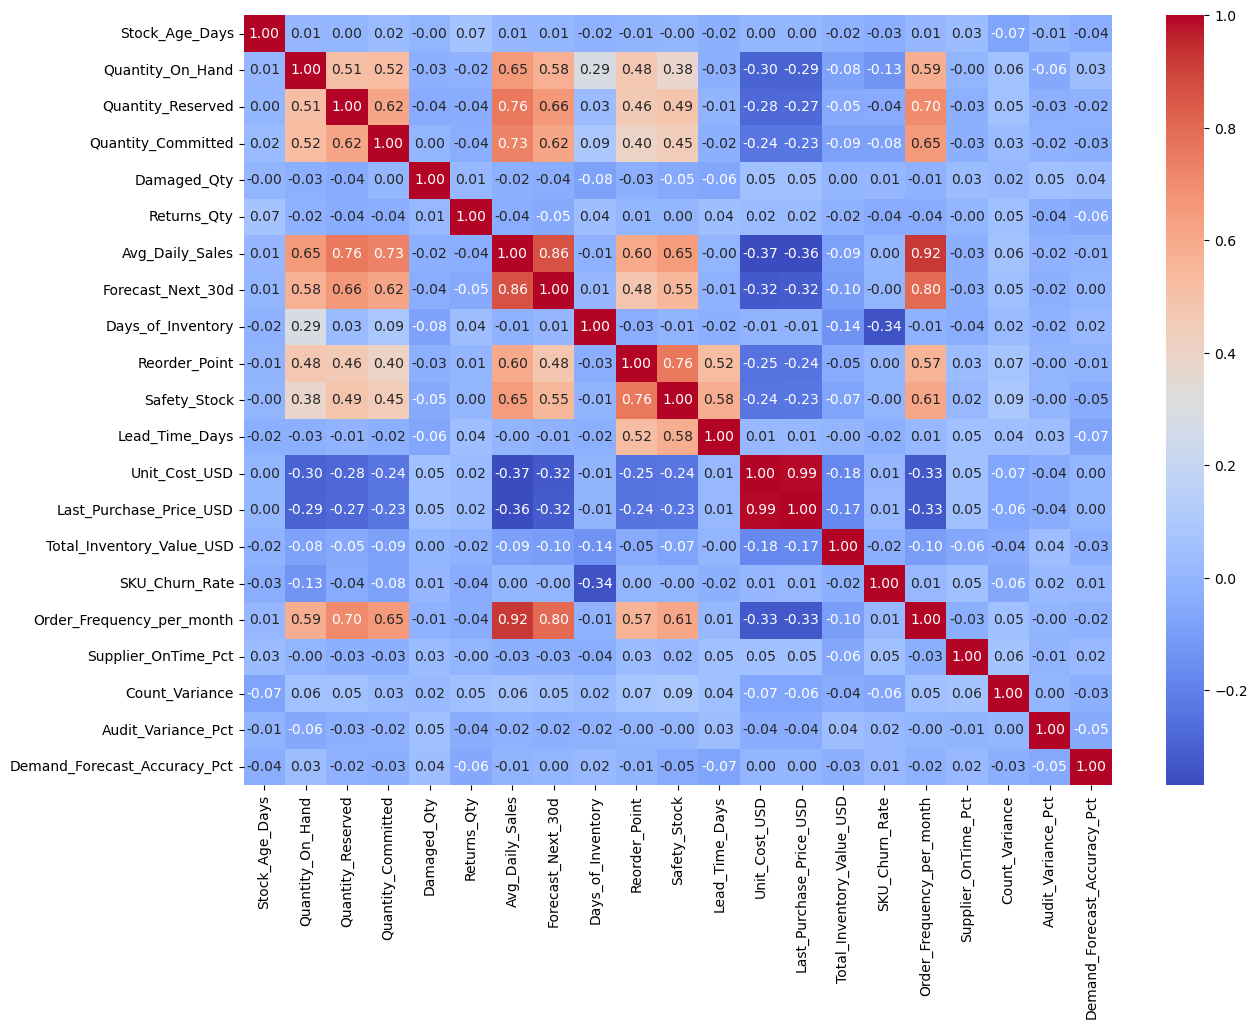

In [83]:
corr = data.corr(numeric_only=True)

# Correlation plot
plt.figure(figsize=(14, 10)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

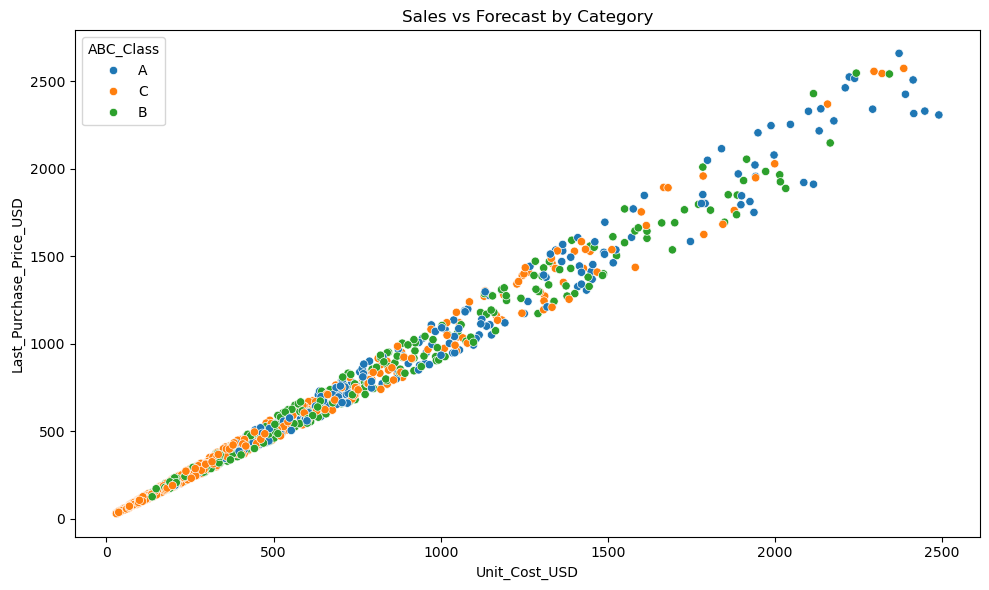

In [118]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='Unit_Cost_USD',
    y='Last_Purchase_Price_USD',
    hue='ABC_Class'  
)

plt.title("Sales vs Forecast by Category")
plt.tight_layout()
plt.show()

Training a Naive Bayes model as a baseline model

In [188]:
X = data.drop(columns=["ABC_Class"])
y = data["ABC_Class"]

In [189]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

In [195]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

In [196]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

In [197]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [199]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [200]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.415

Confusion Matrix:
 [[15  9 14]
 [10 19 24]
 [24 36 49]]

Classification Report:
               precision    recall  f1-score   support

           A       0.31      0.39      0.34        38
           B       0.30      0.36      0.32        53
           C       0.56      0.45      0.50       109

    accuracy                           0.41       200
   macro avg       0.39      0.40      0.39       200
weighted avg       0.44      0.41      0.42       200

